In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
# asyncpg: 비동기, httpx: 외부 API(http)비동기 호출
%pip install asyncpg httpx python-dotenv
%pip install requests


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
from dotenv import load_dotenv
import os

load_dotenv()

print(os.getenv("KAKAO_REST_API_KEY"))

73923fe6c9aff51e1c382ad85842e6ce


In [2]:
# 테스트용 초기 state 만들기
from core.state import make_initial_state
from core.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)

In [3]:
# [노드] preprocess_input
# 사용자 입력 전처리 (변수값 매핑 + 키워드 및 반경 설정)
from nodes.preprocess_input import preprocess_input

preprocess_result = preprocess_input(initial_state)
print("preprocess_input 결과:", preprocess_result)


preprocess_input 결과: {'user_input': {'destination': '홍대역', 'lat': 37.5572, 'lng': 126.9245, 'travel_days': 2, 'companion': 'couple', 'age_group': '20s', 'moods': ['active', 'healing', 'clean'], 'activities': ['thrill/experience', 'performance/culture', 'entertainment/sports', 'nature/walk'], 'transport': 'walk', 'avoid_activities': ['노래'], 'start_time': '09:00', 'end_time': '22:00', 'center_lat': 37.5572, 'center_lng': 126.9245, 'search_radius_km': 2.0, 'final_keywords': ['맛집', '카페', '스릴/체험', '공연/문화', '오락/스포츠', '자연/산책', '숙박'], 'companion_kr': '연인', 'age_group_kr': '20대', 'moods_kr': ['활기찬', '힐링', '깔끔한'], 'activities_kr': ['스릴/체험', '공연/문화', '오락/스포츠', '자연/산책'], 'transport_kr': '도보', 'duration_kr': '1박2일'}, 'warnings': [], 'step': 'preprocessed'}


In [4]:
# [노드] collect_candidate_pool
# kakao Local API로 raw 후보 풀 수집 + PostgreSQL
from nodes.collect_candidate_pool import collect_candidate_pool

candidates_result = await collect_candidate_pool(preprocess_result)
print("candidates_result 결과:", candidates_result)


candidates_result 결과: {'user_input': {'destination': '홍대역', 'lat': 37.5572, 'lng': 126.9245, 'travel_days': 2, 'companion': 'couple', 'age_group': '20s', 'moods': ['active', 'healing', 'clean'], 'activities': ['thrill/experience', 'performance/culture', 'entertainment/sports', 'nature/walk'], 'transport': 'walk', 'avoid_activities': ['노래'], 'start_time': '09:00', 'end_time': '22:00', 'center_lat': 37.5572, 'center_lng': 126.9245, 'search_radius_km': 2.0, 'final_keywords': ['맛집', '음식점', '카페', '찻집', '한옥카페', '루프탑카페', '방탈출카페', '만화카페', '동물카페', '짚라인', '번지점프', '놀이공원', '워터파크', '테마파크', 'VR체험', '이색체험', '서핑', '패러글라이딩', 'ATV', '공연장', '극장', '콘서트홀', '라이브하우스', '영화관', '뮤지컬', '오락실', '볼링장', '당구장', '사격장', '스포츠 시설', '클라이밍', 'PC방', '노래방', '보드게임카페', '공원', '산책로', '둘레길', '식물원', '해변', '바다', '해수욕장', '등산', '산', '계곡', '폭포', '갯벌', '숙박', '호텔', '게스트하우스', '펜션', '리조트', '모텔'], 'companion_kr': '연인', 'age_group_kr': '20대', 'moods_kr': ['활기찬', '힐링', '깔끔한'], 'activities_kr': ['스릴/체험', '공연/문화', '오락/스포츠', '자연/산책'], 'transpor

In [5]:
# [노드] first_filter_candidates
# 첫번쨰 필터 -> travel_days 기반 동적 cap으로 축약
from nodes.first_filter_candidates import first_filter_candidates

filter_result = first_filter_candidates(candidates_result, debug=True)

print(f"\n📌 warnings:")
for w in filter_result["warnings"]:
    print(f"   - {w}")



📦 시작
   ──────────────────────────────────────────────────
   ✂️  제거: 0개  |  남은: 849개
   📊 카테고리: :349  CE7:168  AD5:126  FD6:109  CT1:78  AT4:7
🔍 전체 장소 목록:
01. [FD6] 형님 저요 | 음식점 > 한식 > 육류,고기
02. [CE7] 카페장쌤 | 음식점 > 카페
03. [FD6] 마포곱창타운 | 음식점 > 한식 > 육류,고기 > 곱창,막창
04. [FD6] 비스트로주라 홍대점 | 음식점 > 양식
05. [FD6] 츠케루 | 음식점 > 일식 > 일본식라면
06. [FD6] 일편등심 | 음식점 > 한식 > 육류,고기
07. [FD6] 동보성 | 음식점 > 중식 > 중국요리
08. [FD6] 홍스쭈꾸미 홍대본점 | 음식점 > 한식 > 해물,생선
09. [FD6] 토모토카레 홍대점 | 음식점 > 일식
10. [FD6] 옛날집참숯구이 | 음식점 > 한식 > 육류,고기
11. [FD6] 이츠모라멘 | 음식점 > 일식 > 일본식라면
12. [FD6] 장인닭갈비 홍대점 | 음식점 > 한식 > 육류,고기 > 닭요리
13. [CE7] 1984 | 음식점 > 카페 > 테마카페 > 북카페
14. [FD6] 미쓰족발 홍대본점 | 음식점 > 한식 > 육류,고기 > 족발,보쌈
15. [FD6] 오비야 | 음식점 > 일식 > 일식집
16. [CE7] 샌드커피 논탄토 | 음식점 > 카페
17. [CE7] 덴앤데어 | 음식점 > 카페
18. [CE7] 토라비 | 음식점 > 카페 > 테마카페 > 디저트카페
19. [FD6] 하카타나카 | 음식점 > 일식
20. [FD6] 푸하하크림빵 | 음식점 > 간식 > 제과,베이커리
21. [FD6] 가미우동 | 음식점 > 일식 > 돈까스,우동
22. [FD6] 하이디라오 홍대지점 | 음식점 > 중식 > 중국요리
23. [CE7] 도자기카페줄 | 음식점 > 카페 > 테마카페
24. [FD6] 홍구삼겹 | 음식점 > 한식 > 육류,고

In [6]:
# [노드] second_filter_candidates
# 두번쨰 필터 -> 축소
from nodes.second_filter_candidates import second_filter_candidates

test_state = {
    "filtered_candidates": filter_result["filtered_candidates"],
    "user_input": filter_result["user_input"],
    "warnings": [],
}

second_filter_result = await second_filter_candidates(test_state)

print(f"⚠️ warnings: {second_filter_result['warnings']}")
print(f"✅ step: {second_filter_result['step']}")
print(f"📦 보강된 장소 수: {len(second_filter_result['filtered_candidates'])}")
print(f"📊 scored_candidates 수: {len(second_filter_result['scored_candidates'])}")
print(f"🏆 shortlist 수: {len(second_filter_result['shortlist'])}")

print("\n=== 전체 scored_candidates ===")

for i, s in enumerate(second_filter_result["scored_candidates"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  분위기: {p.get('atmosphere')}
  추천대상: {p.get('best_for')}
  활동: {p.get('place_tags')}
  재방문의사: {p.get('revisit_intent')}
  한줄요약: {p.get('summary')}
  mood_score: {s['mood_score']}
  party_fit_score: {s['party_fit_score']}
  total_score: {s['total_score']}
""")


print("\n=== shortlist ===")

for i, s in enumerate(second_filter_result["shortlist"], 1):
    p = s["place"]

    print(f"""
{i}위. {p['name']}
  total_score: {s['total_score']}
  bucket: {p.get('bucket')}
""")

⏱  네이버 블로그: 21.3초 (97개)
⏱  LLM 보강: 11.5초 (97개)
⚠️ warnings: []
✅ step: enriched
📦 보강된 장소 수: 97
📊 scored_candidates 수: 97
🏆 shortlist 수: 60

=== 전체 scored_candidates ===

1위. 호텔캠퍼스
  분위기: ['깔끔한', '힐링']
  추천대상: ['연인']
  활동: None
  재방문의사: medium
  한줄요약: 깔끔하고 편안한 숙소
  mood_score: 66.7
  party_fit_score: 40
  total_score: 121.7


2위. 머큐어 앰배서더 서울 홍대
  분위기: ['힐링', '깔끔한']
  추천대상: ['연인']
  활동: None
  재방문의사: medium
  한줄요약: 편안하고 깔끔한 숙소
  mood_score: 66.7
  party_fit_score: 40
  total_score: 121.7


3위. 마포곱창타운
  분위기: ['활기찬']
  추천대상: ['연인', '친구']
  활동: None
  재방문의사: high
  한줄요약: 마포곱창타운, 곱창 맛집
  mood_score: 33.3
  party_fit_score: 40
  total_score: 103.3


4위. 비스트로주라 홍대점
  분위기: ['활기찬', '감성']
  추천대상: ['연인', '친구']
  활동: None
  재방문의사: high
  한줄요약: 비스트로주라, 홍대의 붐비는 맛집
  mood_score: 33.3
  party_fit_score: 40
  total_score: 103.3


5위. 일편등심
  분위기: ['활기찬']
  추천대상: ['연인', '친구']
  활동: None
  재방문의사: high
  한줄요약: 일편등심, 고기 맛집
  mood_score: 33.3
  party_fit_score: 40
  total_score: 103.3


6위. 홍스쭈꾸미 홍대본점
  분위기: 

In [7]:
# [노드] travel_matrix
# shortlist 30개 장소 간 이동시간 행렬 계산
from nodes.travel_matrix import travel_matrix

matrix_result = travel_matrix(second_filter_result)

# place_id → name 매핑
id_to_name = {item["place"]["id"]: item["place"]["name"] for item in second_filter_result["shortlist"]}

print(f"✅ place_index: {len(matrix_result['place_index'])}개")
print(f"✅ distance_matrix: {len(matrix_result['distance_matrix'])}x{len(matrix_result['distance_matrix'][0])}")
print(f"✅ time_matrix: {len(matrix_result['time_matrix'])}x{len(matrix_result['time_matrix'][0])}")

for i, from_id in enumerate(matrix_result['place_index']):
    print(f"\n📍 {id_to_name[from_id]} 에서:")
    for to_id, mins in zip(matrix_result['place_index'], matrix_result['time_matrix'][i]):
        if from_id == to_id:
            continue
        print(f"  → {id_to_name[to_id]}: {mins}분")

✅ place_index: 60개
✅ distance_matrix: 60x60
✅ time_matrix: 60x60

📍 호텔캠퍼스 에서:
  → 머큐어 앰배서더 서울 홍대: 20.6분
  → 마포곱창타운: 21.0분
  → 비스트로주라 홍대점: 18.1분
  → 일편등심: 18.0분
  → 홍스쭈꾸미 홍대본점: 15.8분
  → 이츠모라멘: 18.1분
  → 오비야: 18.1분
  → 하카타나카: 19.0분
  → 하이디라오 홍대지점: 17.6분
  → BBQ 홍대반가점: 17.9분
  → 트릭아이뮤지엄: 22.0분
  → 경의선숲길: 17.3분
  → 경의선숲길: 21.6분
  → 와우공원: 13.7분
  → 노고산: 7.5분
  → 아로마인드: 30.5분
  → 리얼샷사격양궁장 홍대점: 23.1분
  → 액티브아레나 홍대점: 21.6분
  → 케이 탑건 홍대점: 18.2분
  → 홍제천: 35.6분
  → L7 홍대바이롯데: 21.8분
  → 아늑 호텔 홍대: 23.4분
  → 아만티호텔서울 웨딩: 25.6분
  → 만동제과: 16.7분
  → 덴앤데어: 18.0분
  → 형님 저요: 17.2분
  → 츠케루: 18.6분
  → 토모토카레 홍대점: 12.9분
  → 가미우동: 18.9분
  → 사천리훠궈 홍대점: 19.2분
  → 벌툰 봉화당 홍대입구역점: 17.0분
  → 구름아래소극장: 13.0분
  → 리얼샷사격장 홍대점: 21.1분
  → 윗잔다리어린이공원: 15.8분
  → 스페이스 458: 30.2분
  → 마포아트센터 갤러리맥: 14.1분
  → WDG스튜디오 홍대: 19.5분
  → 이노호스텔&펍라운지 홍대점: 31.7분
  → 홀리데이 인 익스프레스 서울 홍대: 15.1분
  → 나비호스텔: 17.8분
  → 벌툰 인더스트리얼 홍대본점: 25.5분
  → 카페장쌤: 14.7분
  → 1984: 20.1분
  → 샌드커피 논탄토: 19.0분
  → 토라비: 16.5분
  → 스머프 매직 포레스트 홍대점: 15.0분
  → KT&G상상마당 홍

In [9]:
# [노드] plan_itinerary
from nodes.plan_itinerary import plan_itinerary

plan_state = {**matrix_result, "shortlist": second_filter_result["shortlist"], "user_input": second_filter_result["user_input"]}
itinerary_result = plan_itinerary(plan_state)

print(f"✅ 총 {len(itinerary_result['itineraries'])}개 동선")
print()

# 전체 동선 출력
for idx, itinerary in enumerate(itinerary_result["itineraries"], 1):
    print(f"\n{'='*50}")
    print(f"동선 {idx}번")
    print(f"{'='*50}")
    for item in itinerary:
        p = item["place"]
        print(f"{item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
        print(f"   도착: {item['arrive_at']}  출발: {item['leave_at']}  다음까지: {item['travel_to_next_minutes']}분")
    print()

전체 동선: 111개
이동시간 초과 제거: 6개
bucket 연속 제거: 26개
경로 교차 제거: 70개
조건 통과: 9개
중복 제거 후: 9개
✅ 총 9개 동선


동선 1번
1. [activity] 경의선숲길
   도착: 09:00  출발: 11:00  다음까지: 5분
2. [cafe    ] 만동제과
   도착: 11:05  출발: 12:05  다음까지: 7분
3. [food    ] 마포곱창타운
   도착: 12:13  출발: 13:13  다음까지: 8분
4. [cafe    ] 도자기카페줄
   도착: 13:21  출발: 14:21  다음까지: 1분
5. [activity] 미디어극장아이공
   도착: 14:23  출발: 16:23  다음까지: 8분
6. [activity] 와우산
   도착: 16:31  출발: 18:31  다음까지: 6분
7. [food    ] 이츠모라멘
   도착: 18:38  출발: 19:38  다음까지: 3분
8. [activity] 리얼샷사격장 홍대점
   도착: 19:41  출발: 21:41  다음까지: 4분
9. [lodging ] 아늑 호텔 홍대
   도착: 21:45  출발: -  다음까지: 0분


동선 2번
1. [activity] 리얼샷사격양궁장 홍대점
   도착: 09:00  출발: 11:00  다음까지: 13분
2. [cafe    ] 도자기카페줄
   도착: 11:13  출발: 12:13  다음까지: 3분
3. [food    ] 홍스쭈꾸미 홍대본점
   도착: 12:16  출발: 13:16  다음까지: 1분
4. [activity] 스머프 매직 포레스트 홍대점
   도착: 13:18  출발: 15:18  다음까지: 1분
5. [activity] 윗잔다리어린이공원
   도착: 15:19  출발: 17:19  다음까지: 2분
6. [cafe    ] 토라비
   도착: 17:22  출발: 18:22  다음까지: 2분
7. [food    ] 일편등심
   도착: 18:24  출발: 19:24  다음까지: 4

In [11]:
# [노드] select_itinerary
from nodes.select_itinerary import select_itinerary

select_state = {
    **itinerary_result,
    "user_input": second_filter_result["user_input"],
}
select_itinerary_result = await select_itinerary(select_state)

print(f"✅ step: {select_itinerary_result['step']}")
print(f"✅ 선택된 동선 day 수: {len(select_itinerary_result['selected_itinerary'])}")
print()
for day in select_itinerary_result["selected_itinerary"]:
    print(f"\n=== Day {day['day_number']} ===")
    for item in day["itinerary"]:
        p = item["place"]
        print(f"{item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
        print(f"   도착: {item['arrive_at']}  추천이유: {item['recommendation_reason']}")

✅ step: selected
✅ 선택된 동선 day 수: 2


=== Day 1 ===
1. [cafe    ] 홈즈앤루팡 해운대점
   도착: 09:00  추천이유: 보드게임과 함께하는 활기찬 카페
2. [activity] 동백공원 해안산책로
   도착: 10:14  추천이유: 해안산책로에서의 편안한 산책
3. [food    ] 부다면옥
   도착: 12:33  추천이유: 미쉐린 평양냉면, 여름에 딱!
4. [other   ] 바다내음공원
   도착: 13:45  추천이유: 바다뷰가 멋진 공원
5. [activity] 레드포스 pc 해운대점
   도착: 14:59  추천이유: 깔끔한 분위기의 해운대 PC방
6. [food    ] 해운대할매집
   도착: 17:02  추천이유: 해운대 국밥 맛집, 육수 최고
7. [activity] 롯데시네마 프리미엄해운대
   도착: 18:21  추천이유: 편안한 영화 관람을 위한 장소
8. [cafe    ] 블랙업커피 해운대점
   도착: 20:40  추천이유: 맛있는 커피가 있는 카페
9. [lodging ] 어반스테이 해운대역
   도착: 21:48  추천이유: 

=== Day 2 ===
1. [activity] 해운대블루라인파크 미포정거장
   도착: 09:00  추천이유: 포토존이 매력적인 테마파크
2. [activity] 씨라이프 부산아쿠아리움
   도착: 11:16  추천이유: 아쿠아리움에서의 특별한 경험
3. [food    ] 해목
   도착: 13:20  추천이유: 고급스러운 일본식 장어덮밥
4. [activity] 동백섬 누리마루전망대
   도착: 14:39  추천이유: 탁 트인 전망의 멋진 장소
5. [food    ] 고래사어묵 해운대점
   도착: 16:59  추천이유: 부산 유명 어묵 맛집
6. [activity] 왕미미오락실
   도착: 18:00  추천이유: 대형 오락실, 가족과 즐기기 좋은
7. [cafe    ] 옵스 해운대점
   도착: 20:04  추천이유: 부산 유명 빵집, 

In [13]:
# [노드] generate_response
from nodes.generate_response import generate_response

generate_state = {
    **select_itinerary_result,
    "user_input": second_filter_result["user_input"],
}
response_result = generate_response(generate_state)

print(f"✅ step: {response_result['step']}")
print()

import json
print(json.dumps(response_result["response"], ensure_ascii=False, indent=2))

✅ step: done

{
  "days": [
    {
      "dayNumber": 1,
      "places": [
        {
          "placeOrder": 1,
          "placeId": "1822809501",
          "name": "홈즈앤루팡 해운대점",
          "address": "부산 해운대구 해운대해변로265번길 13",
          "placeUrl": "http://place.map.kakao.com/1822809501",
          "lat": 35.1607272642564,
          "lng": 129.160822633594,
          "description": "보드게임과 함께하는 활기찬 카페",
          "stayMinutes": 60,
          "arriveTime": "09:00",
          "transportToNext": "walk",
          "travelMinutesToNext": 14
        },
        {
          "placeOrder": 2,
          "placeId": "17807211",
          "name": "동백공원 해안산책로",
          "address": "",
          "placeUrl": "http://place.map.kakao.com/17807211",
          "lat": 35.1544084334923,
          "lng": 129.153285352622,
          "description": "해안산책로에서의 편안한 산책",
          "stayMinutes": 120,
          "arriveTime": "10:14",
          "transportToNext": "walk",
          "travelMinutesToNext": 18
        },
 

In [11]:
# LangGraph 그래프 빌드
from langgraph.graph import StateGraph, START, END
from core.state import TravelState

graph_builder = StateGraph(TravelState)

# 노드 등록
graph_builder.add_node("preprocess_input", preprocess_input)
graph_builder.add_node("collect_candidate_pool", collect_candidate_pool)
graph_builder.add_node("first_filter_candidates", first_filter_candidates)
graph_builder.add_node("second_filter_candidates", second_filter_candidates)
graph_builder.add_node("travel_matrix", travel_matrix)
graph_builder.add_node("plan_itinerary", plan_itinerary)
graph_builder.add_node("select_itinerary", select_itinerary)
# graph_builder.add_node("generate_response", generate_response)

# 엣지 (직선 연결)
graph_builder.add_edge(START, "preprocess_input")
graph_builder.add_edge("preprocess_input", "collect_candidate_pool")
graph_builder.add_edge("collect_candidate_pool", "first_filter_candidates")
graph_builder.add_edge("first_filter_candidates", "second_filter_candidates")
graph_builder.add_edge("second_filter_candidates", "travel_matrix")
graph_builder.add_edge("travel_matrix", "plan_itinerary")
graph_builder.add_edge("plan_itinerary", "select_itinerary")
graph_builder.add_edge("select_itinerary", "generate_response")
graph_builder.add_edge("generate_response", END)

graph = graph_builder.compile()

In [12]:
# 그래프 실행
from core.state import make_initial_state
from core.mocks import mock_user_input

initial_state = make_initial_state(mock_user_input)
state_v1 = await graph.ainvoke(initial_state)

print(f"📍 위치: {state_v1['user_input']['location']}")
print(f"📌 좌표: ({state_v1['user_input']['center_lat']}, {state_v1['user_input']['center_lng']})")
print(f"🔍 Kakao raw 후보: {len(state_v1['candidates'])}개")
print(f"✅ step: {state_v1['step']}")
print(f"✅ next_node: {state_v1.get('next_node', '')}")
print(f"⚠️  warnings: {state_v1['warnings']}")
print(f"❌ errors: {state_v1['errors']}")
print()

print(f"📋 itinerary ({len(state_v1['itinerary'])}개 장소):")
for item in state_v1["itinerary"]:
    p = item["place"]
    print(f"  {item['order']}. [{p.get('bucket','?'):8}] {p['name']}")
    print(f"     도착: {item['arrive_at']}  출발: {item['leave_at']}  다음까지: {item['travel_to_next_minutes']}분")

if state_v1.get("violations"):
    print(f"\n❌ violations:")
    for v in state_v1["violations"]:
        print(f"  - {v['reason']}: {v['detail']}")

⏱  네이버 블로그: 10.5초 (50개)
⏱  LLM 보강: 16.2초 (50개)
⏱  네이버 블로그: 10.4초 (50개)
⏱  LLM 보강: 16.6초 (50개)
⏱  네이버 블로그: 10.5초 (50개)
⏱  LLM 보강: 15.3초 (50개)
📍 위치: 해운대역
📌 좌표: (35.1636479638612, 129.158897240251)
🔍 Kakao raw 후보: 275개
✅ step: constraint_passed
✅ next_node: 
⚠️  warnings: []
❌ errors: []

📋 itinerary (9개 장소):
  1. [cafe    ] 블랙업커피 해운대점
     도착: 09:00  출발: 10:00  다음까지: 0분
  2. [activity] 할매탕
     도착: 10:00  출발: 12:00  다음까지: 7분
  3. [food    ] 빨간떡볶이
     도착: 12:08  출발: 13:08  다음까지: 3분
  4. [cafe    ] 딥플로우커피
     도착: 13:11  출발: 14:11  다음까지: 2분
  5. [activity] 플레이포인트랩 해운대 블루오션스테이션점
     도착: 14:14  출발: 16:14  다음까지: 1분
  6. [food    ] 고래사어묵 해운대점
     도착: 16:15  출발: 17:15  다음까지: 5분
  7. [cafe    ] 워킹홀리데이 해운대
     도착: 17:21  출발: 18:21  다음까지: 1분
  8. [other   ] 씨라이프 부산아쿠아리움
     도착: 18:22  출발: 19:22  다음까지: 1분
  9. [other   ] 해변문화관
     도착: 19:23  출발: 20:23  다음까지: 0분


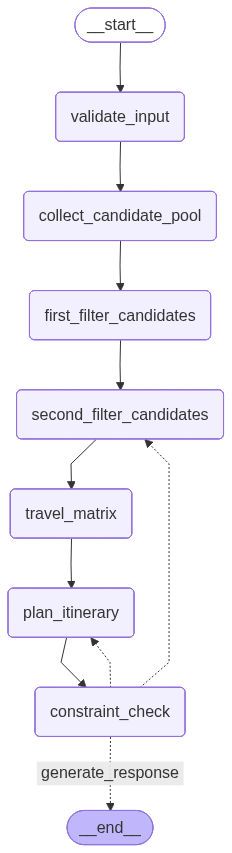

In [13]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))